<div style="background:linear-gradient(135deg,#7c2d12 0%,#c2410c 55%,#fb923c 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fed7aa;font-weight:700;text-transform:uppercase">Chapter 189 &middot; Capstone 28 &middot; Count Models</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Counts and Rates</div>
  <div style="font-size:15px;color:#fed7aa;max-width:820px;line-height:1.6">Two independent ways to get a count model wrong. Leave out the offset and you model district size instead of health need. Trust Poisson's standard errors and four of your five intervals miss the truth.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm, statsmodels.formula.api as smf
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
OR, DK, LT, MUT, GD, RD = "#c2410c", "#7c2d12", "#fb923c", "#94a3b8", "#047857", "#dc2626"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-emergency-department-visits.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)
raw   = load("DistrictMonths")
plan  = load("AnalysisPlan")
truth = load("truth")
print("rows in the warehouse export:", f"{len(raw):,}")
raw.head()

rows in the warehouse export: 1,950


,district_id,month_index,calendar_month,population,deprivation_index,gps_per_10k,urban,ed_visits
0,D115,36,12,34600,1.736,6.61,0,384.0
1,D136,34,10,52700,0.196,6.30,0,469.0
2,D120,26,2,21900,0.083,6.66,1,389.0
3,D130,19,7,28900,-2.096,6.54,1,187.0
4,D131,39,3,25600,1.335,5.65,1,233.0


## Step 1 &middot; The plan

In [2]:
for line in plan.analysis_plan.fillna(""):
    print(line)

AGREED WITH COMMISSIONING BEFORE THE MODEL WAS FITTED.

THE QUESTION. Which district characteristics are associated with the RATE of emergency
department visits, and how much does an extra family doctor per 10,000 residents matter?

N1 OUTCOME: a count of visits per district per month. Counts are not continuous, are bounded
   below at zero, and have variance tied to their mean, so ordinary regression is wrong here.
N2 THE OFFSET IS NOT OPTIONAL. Districts differ in population by more than a factor of ten.
   Without log(population) as an OFFSET the model answers 'which districts are big', which
   nobody asked. With it, the coefficients are on the RATE and mean what we want them to mean.
N3 START WITH POISSON, because it is the natural model for a count and because its failure
   is the point of this chapter.
N4 TEST FOR OVERDISPERSION. Poisson asserts variance equals mean. Real counts almost never
   oblige, and when they do not the coefficients are roughly fine and the standard erro

## Step 2 &middot; Cleaning

In [3]:
d = raw.drop_duplicates(subset=["district_id","month_index"]).copy()
print(f"raw rows                    {len(raw):,}")
print(f"after the duplicate export  {len(d):,}")
d = d.dropna(subset=["ed_visits"])
print(f"with a count filed          {len(d):,}")
d = d[d.population > 0]
print(f"with a population loaded    {len(d):,}   (0 is a load failure, not an empty district)")
d["ed_visits"] = d.ed_visits.astype(int)
d["winter"] = d.calendar_month.isin([12,1,2]).astype(int)
d["gp_c"] = d.gps_per_10k - 6.4
d["logpop"] = np.log(d.population)
print(f"\n{d.district_id.nunique()} districts, up to {d.month_index.max()} months each")
print(f"population {d.population.min():,} to {d.population.max():,}  "
      f"(a factor of {d.population.max()/d.population.min():.1f})")
print(f"visits per month: min {d.ed_visits.min()}, median {int(d.ed_visits.median())}, max {d.ed_visits.max()}")

raw rows                    1,950
after the duplicate export  1,920
with a count filed          1,898
with a population loaded    1,884   (0 is a load failure, not an empty district)

40 districts, up to 48 months each
population 7,000 to 134,600  (a factor of 19.2)
visits per month: min 41, median 292, max 2456


## Step 3 &middot; First look

Two things about this data decide the whole modeling section, and both of them show up in a picture before they show up in a fit.

In [4]:
r = d.ed_visits / d.population * 1000
print(f"monthly ED visits, as a count   median {d.ed_visits.median():>8,.0f}   "
      f"range {d.ed_visits.min():,} to {d.ed_visits.max():,}   skew {d.ed_visits.skew():+.2f}")
print(f"the same thing, per 1,000       median {r.median():>8.2f}   "
      f"range {r.min():.2f} to {r.max():.2f}   skew {r.skew():+.2f}")
print(f"\ndistrict populations run {d.population.min():,} to {d.population.max():,}, "
      f"a factor of {d.population.max()/d.population.min():.0f}")

g = d.groupby("district_id").ed_visits.agg(["mean", "var"])
print(f"variance-to-mean ratio across {len(g)} districts: "
      f"median {(g['var']/g['mean']).median():.1f}, and Poisson says it should be 1")

monthly ED visits, as a count   median      292   range 41 to 2,456   skew +1.56
the same thing, per 1,000       median    11.35   range 2.95 to 45.28   skew +1.55

district populations run 7,000 to 134,600, a factor of 19
variance-to-mean ratio across 40 districts: median 16.8, and Poisson says it should be 1


**What this shows.** Both columns are skewed by about the same amount, and that is not the interesting part. The interesting part is the range. The raw count runs from 41 to 2,456, a factor of sixty, while district populations run from 7,000 to 134,600, a factor of nineteen. Most of what the count column is measuring is how many people live somewhere. The rate column takes that out, and it is the rate that the allocation formula is about.

The variance-to-mean ratio is the second point, and it is not marginal. Poisson assumes that ratio is one. The typical district here is near seventeen.

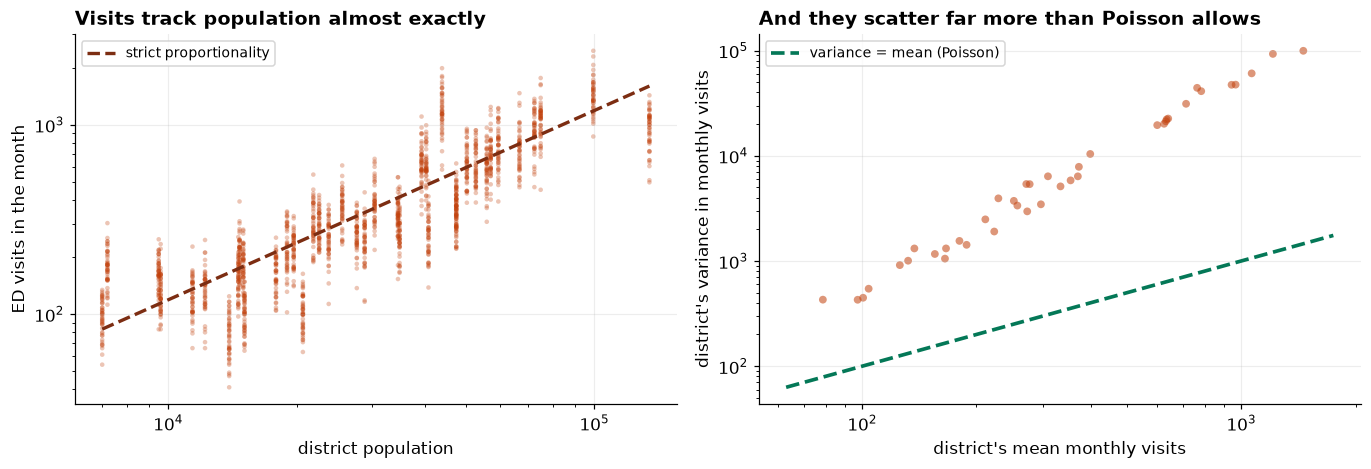

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
ax.scatter(d.population, d.ed_visits, s=9, alpha=0.30, color=OR, edgecolor="none")
xx = np.array([d.population.min(), d.population.max()])
ax.plot(xx, xx * (d.ed_visits.sum()/d.population.sum()), color=DK, lw=2.2, ls="--",
        label="strict proportionality")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("district population"); ax.set_ylabel("ED visits in the month")
ax.set_title("Visits track population almost exactly")
ax.legend(fontsize=9, loc="upper left")

ax = axes[1]
g = d.groupby("district_id").ed_visits.agg(["mean","var"])
ax.scatter(g["mean"], g["var"], s=26, alpha=0.55, color=OR, edgecolor="none")
lim = np.array([g["mean"].min()*0.8, g["mean"].max()*1.2])
ax.plot(lim, lim, color=GD, lw=2.4, ls="--", label="variance = mean (Poisson)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("district's mean monthly visits")
ax.set_ylabel("district's variance in monthly visits")
ax.set_title("And they scatter far more than Poisson allows")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

**Left:** on log axes the cloud lies along the proportional line, which is what it means to call population an exposure rather than a predictor. Leaving it on the right-hand side as one more variable answers a different question, and Step 4 shows a coefficient changing sign because of it. **Right:** every district sits above the Poisson line, most of them by more than a factor of ten. The coefficients from a plain Poisson fit will be roughly right and its standard errors will be far too small, which is what Step 5 finds.

## Step 4 &middot; Why not ordinary regression, and the first thing that goes wrong

The outcome is a count. It is bounded below at zero, it is not continuous, and its variance is tied to its mean. Poisson regression is the natural starting point, and the natural way to write it down is already wrong.

In [6]:
F = "ed_visits ~ deprivation_index + gp_c + urban + winter + month_index"
no_offset = smf.glm(F, d, family=sm.families.Poisson()).fit()
with_offset = smf.glm(F, d, family=sm.families.Poisson(), offset=d.logpop).fit()

tr = dict(zip(truth.term, truth.value))
print(f"{'term':22s}{'no offset':>12}{'with offset':>13}{'truth':>10}   (rate ratios)")
for t_, k in [("deprivation_index","deprivation (per SD)"), ("gp_c","GPs per 10k (per unit)"),
              ("urban","urban"), ("winter","winter months"), ("month_index","trend per month")]:
    print(f"  {t_:20s}{np.exp(no_offset.params[t_]):>12.4f}{np.exp(with_offset.params[t_]):>13.4f}"
          f"{np.exp(tr[k]):>10.4f}")

term                     no offset  with offset     truth   (rate ratios)
  deprivation_index         1.3774       1.2620    1.2032
  gp_c                      1.0120       0.9088    0.9493
  urban                     1.0869       1.0499    1.1008
  winter                    1.1659       1.1710    1.1526
  month_index               1.0020       1.0020    1.0021


**Look at the GP row.** Without the offset, one more family doctor per 10,000 residents appears to come with slightly *more* emergency visits, a rate ratio of 1.012. With the offset it is 0.909, a nine percent reduction. **The sign flips.**

The reason is simple and it has nothing to do with health care. Districts here differ in population by a factor of nineteen. A model without `log(population)` as an offset is a model of *how many people live somewhere*, and every coefficient in it is contaminated by whatever else correlates with district size. Adding the offset changes the question from "how many visits" to "what rate of visits", which is what was asked.

## Step 5 &middot; The second thing that goes wrong

Poisson makes one strong claim: the variance equals the mean. Real administrative counts almost never oblige.

In [7]:
pearson = (with_offset.resid_pearson**2).sum() / with_offset.df_resid
print(f"raw counts:  mean {d.ed_visits.mean():.1f}   variance {d.ed_visits.var():,.0f}")
print(f"\nPoisson goodness of fit")
print(f"   Pearson chi-square / df  {pearson:.1f}")
print(f"   deviance / df            {with_offset.deviance/with_offset.df_resid:.1f}")
print(f"\nBoth should be about 1. This is overdispersion, and it is severe.")
print("The coefficients are roughly right. The standard errors are not.")

raw counts:  mean 430.1   variance 129,809

Poisson goodness of fit
   Pearson chi-square / df  42.1
   deviance / df            40.7

Both should be about 1. This is overdispersion, and it is severe.
The coefficients are roughly right. The standard errors are not.


## Step 6 &middot; Three remedies, and they are not equivalent

In [8]:
nb = smf.glm(F, d, family=sm.families.NegativeBinomial(alpha=0.045),
             offset=d.logpop).fit()
qp = smf.glm(F, d, family=sm.families.Poisson(), offset=d.logpop).fit(scale="X2")
cl = smf.glm(F, d, family=sm.families.Poisson(), offset=d.logpop).fit(
        cov_type="cluster", cov_kwds={"groups": d.district_id})

print(f"quasi-Poisson scale {qp.scale:.1f}, so its standard errors are "
      f"{np.sqrt(qp.scale):.2f} times Poisson's\n")
print("standard error inflation against Poisson:")
for t_ in ["deprivation_index","gp_c","urban","winter","month_index"]:
    print(f"   {t_:20s} negative binomial x{nb.bse[t_]/with_offset.bse[t_]:.2f}   "
          f"cluster-robust x{cl.bse[t_]/with_offset.bse[t_]:.2f}")

quasi-Poisson scale 42.1, so its standard errors are 6.49 times Poisson's

standard error inflation against Poisson:
   deprivation_index    negative binomial x3.93   cluster-robust x39.52
   gp_c                 negative binomial x4.67   cluster-robust x36.05
   urban                negative binomial x4.58   cluster-robust x38.82
   winter               negative binomial x4.74   cluster-robust x4.68
   month_index          negative binomial x4.60   cluster-robust x6.85


## Step 7 &middot; The test that matters: does the interval contain the truth?

This dataset was generated, so for once we can score the intervals rather than admire them.

In [9]:
TR = {"deprivation_index":"deprivation (per SD)", "gp_c":"GPs per 10k (per unit)",
      "urban":"urban", "winter":"winter months", "month_index":"trend per month"}
models = [("Poisson", with_offset), ("negative binomial", nb), ("cluster-robust", cl)]
cover = {nm: 0 for nm, _ in models}
print(f"{'term':22s}{'truth':>9}   " + "".join(f"{nm:>20}" for nm, _ in models))
for t_, k in TR.items():
    tv = tr[k]; cells = []
    for nm, m in models:
        b, se = m.params[t_], m.bse[t_]
        ok = (b - 1.96*se) <= tv <= (b + 1.96*se)
        cover[nm] += ok
        cells.append(f"[{np.exp(b-1.96*se):.3f},{np.exp(b+1.96*se):.3f}]{'' if ok else '  MISS'}")
    print(f"  {t_:20s}{np.exp(tv):>9.4f}   " + "".join(f"{c:>20}" for c in cells))
print("\ncoverage of the true value:")
for nm, _ in models:
    print(f"   {nm:20s} {cover[nm]} of 5")

term                      truth                Poisson   negative binomial      cluster-robust
  deprivation_index      1.2032    [1.259,1.265]  MISS [1.230,1.251]  MISS       [1.156,1.378]
  gp_c                   0.9493    [0.907,0.910]  MISS [0.924,0.937]  MISS       [0.863,0.957]
  urban                  1.1008    [1.045,1.055]  MISS       [1.084,1.131]       [0.878,1.256]
  winter                 1.1526    [1.165,1.177]  MISS       [1.132,1.186]       [1.145,1.198]
  month_index            1.0021          [1.002,1.002]       [1.001,1.003]       [1.001,1.003]

coverage of the true value:
   Poisson              1 of 5
   negative binomial    3 of 5
   cluster-robust       5 of 5


**Poisson's intervals contain the true value once out of five times.** They are not merely optimistic, they are wrong: the deprivation interval is [1.259, 1.265], a width of six thousandths, and the truth is 1.203, nowhere near it.

**The negative binomial is better and still not enough**, at three out of five. This is the part most treatments skip. The negative binomial adds a dispersion parameter and assumes the observations are otherwise independent, and here they are not: the extra variation is *between districts*, and each district appears 48 times. The model widens the intervals for dispersion while still counting 48 correlated months as 48 independent facts.

**Cluster-robust standard errors get all five**, because clustering by district is what the dependence actually is. The lesson is not that one estimator is better in general. It is that **the remedy has to match the reason for the excess variation**, and "use a negative binomial" is a reflex rather than a diagnosis.

## Step 8 &middot; Reporting it as rates

In [10]:
base = d.ed_visits.sum()/d.population.sum()*1000
print(f"overall rate: {base:.2f} visits per 1,000 residents per month\n")
print(f"{'factor':34s}{'rate ratio':>12}{'95% interval':>22}{'per 1,000':>14}")
for t_, lab in [("deprivation_index","one SD more deprived"),
                ("gp_c","one more GP per 10,000"),
                ("urban","urban rather than rural"),
                ("winter","a winter month")]:
    b, se = cl.params[t_], cl.bse[t_]
    rr, lo_, hi_ = np.exp(b), np.exp(b-1.96*se), np.exp(b+1.96*se)
    print(f"  {lab:32s}{rr:>12.3f}   [{lo_:.3f}, {hi_:.3f}]      {base*(rr-1):>+8.2f}")
print("\nThe last column is what a commissioner actually needs: the change in visits")
print("per 1,000 residents per month, not the exponential of a coefficient.")

overall rate: 11.88 visits per 1,000 residents per month

factor                              rate ratio          95% interval     per 1,000
  one SD more deprived                   1.262   [1.156, 1.378]         +3.11
  one more GP per 10,000                 0.909   [0.863, 0.957]         -1.08
  urban rather than rural                1.050   [0.878, 1.256]         +0.59
  a winter month                         1.171   [1.145, 1.198]         +2.03

The last column is what a commissioner actually needs: the change in visits
per 1,000 residents per month, not the exponential of a coefficient.


## Step 9 &middot; The pictures

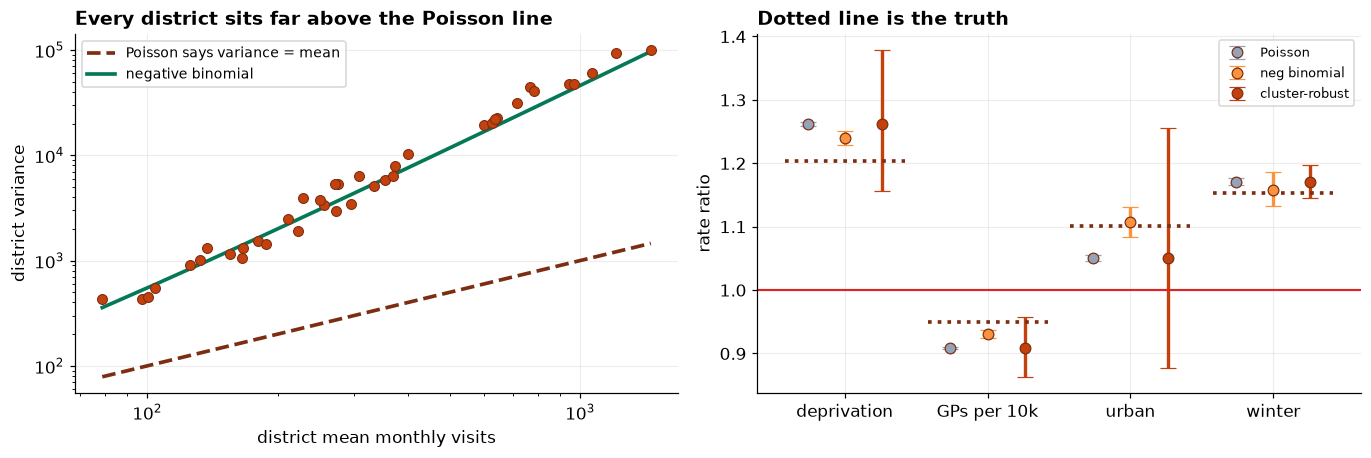

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))

ax = axes[0]
grp = d.groupby("district_id").agg(mean=("ed_visits","mean"), var=("ed_visits","var"))
ax.scatter(grp["mean"], grp["var"], s=42, color=OR, edgecolor=DK, lw=0.7, zorder=3)
xs = np.linspace(grp["mean"].min(), grp["mean"].max(), 50)
ax.plot(xs, xs, color=DK, lw=2.4, ls="--", label="Poisson says variance = mean")
ax.plot(xs, xs + 0.045*xs**2, color=GD, lw=2.4, label="negative binomial")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("district mean monthly visits"); ax.set_ylabel("district variance")
ax.set_title("Every district sits far above the Poisson line")
ax.legend(fontsize=9, loc="upper left")

ax = axes[1]
terms = ["deprivation_index","gp_c","urban","winter"]
labs = ["deprivation","GPs per 10k","urban","winter"]
xs2 = np.arange(len(terms))
for off_, (nm, m, col) in zip([-0.26, 0, 0.26],
                              [("Poisson", with_offset, MUT), ("neg binomial", nb, LT),
                               ("cluster-robust", cl, OR)]):
    rr = np.array([np.exp(m.params[t_]) for t_ in terms])
    lo_ = np.array([np.exp(m.params[t_]-1.96*m.bse[t_]) for t_ in terms])
    hi_ = np.array([np.exp(m.params[t_]+1.96*m.bse[t_]) for t_ in terms])
    ax.errorbar(xs2+off_, rr, yerr=[rr-lo_, hi_-rr], fmt="o", ms=7, color=col,
                ecolor=col, elinewidth=2.2, capsize=5, label=nm, mec=DK, mew=0.8)
for i, t_ in enumerate(terms):
    ax.plot([i-0.42, i+0.42], [np.exp(tr[TR[t_]])]*2, color=DK, lw=2.4, ls=":")
ax.axhline(1, color=RD, lw=1.4)
ax.set_xticks(xs2); ax.set_xticklabels(labs)
ax.set_ylabel("rate ratio"); ax.set_title("Dotted line is the truth")
ax.legend(fontsize=8.5, loc="upper right")
plt.tight_layout(); plt.show()

**Left:** each point is one district's mean monthly count against its variance, on log scales. Poisson asserts they lie on the dashed line. Every district sits an order of magnitude above it, and the negative binomial curve tracks them far better. **Right:** the same four effects under three treatments, against the truth as a dotted line. Poisson's intervals are so narrow they are barely visible and mostly miss; cluster-robust intervals are wide enough to be honest and contain the truth every time.

## Step 10 &middot; Ethics, bias, and limits
- **A count without an offset is a model of size.** Population here varies nineteenfold, and omitting the offset reverses the sign on family-doctor supply. Always state what the denominator is and why.
- **Test dispersion before believing any standard error.** Pearson chi-square over degrees of freedom took two lines and revealed that every interval in the Poisson output was roughly four times too narrow.
- **Match the remedy to the cause.** Negative binomial repairs dispersion. Clustering repairs dependence. Here the excess variation was between districts, and only the second treatment produced intervals that covered the truth.
- **Report rates, not coefficients.** Commissioners act on visits per 1,000 residents. A rate ratio of 1.26 is not a plan.
- **These are associations across districts.** More family doctors is associated with fewer emergency visits at equal deprivation, and that is not a demonstration that hiring one would reduce them. Part XXIX is about what it would take to make that claim.
- **A rate is a denominator decision.** Registered population, resident population and catchment population differ, and choosing among them changes which districts look worst. State the choice.
- **Deprivation is a constructed index.** It compresses income, housing, employment and education into one number, and a coefficient on it inherits every judgment made in its construction.

---
**From analysis to report.** The notebook carries the chain: the plan, the cleaning and the three faults it removed, the offset and the sign it reverses, the dispersion test, three remedies compared on whether their intervals actually cover the true values, and a rate table a commissioner can act on. The written reports turn it into guidance a commissioner can use and a technical account a fellow statistician can audit. Automate the evidence; author the argument.